In [1]:
import torch
import sys
import time

sys.path.append("/home/hpc/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is available: 1 device(s) detected.
Current device id: 0 - NVIDIA A100-SXM4-80GB


In [2]:
from main import load_and_process_config
from models import load_best_model_by_run
from dataset import from_config
from utilities import tensor_dict_summarize


config = load_and_process_config("config_test.yaml")
config.RUN = "lilac-puddle-12"
highlighter = PolarHighlighter(width=448, height=448).cuda()
dataset = from_config(config)["test"]
model = load_best_model_by_run(config.RUN).eval().cuda()

DATASET  [15:59:00] Processing 1 datasets: ['SCARED']

DATASET  [15:59:00] Using all scenes except VAL_SCENES for SCARED training

DATASET  [15:59:00]   ✓ Created training dataset for SCARED: 15420 samples (excluding 13 val scenes)

DATASET  [15:59:00]   ✓ Created validation dataset for SCARED: 11323 samples from 13 scenes

DATASET  [15:59:00] === Dataset Creation Summary ===

...

DATASET  [15:59:00] Test:       11323 total samples

INFO     [15:59:01] Found valid run to resume: /anvme/workspace/v120bb18-unreflectanything/results/lilac-puddle-12

INFO     [15:59:01] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/lilac-puddle-12/models/weights_best.pt

INFO     [15:59:01] Latest epoch: 8

MODEL    [15:59:03] Model with class RGBDistillDecomposer created with 111,351,812 parameters

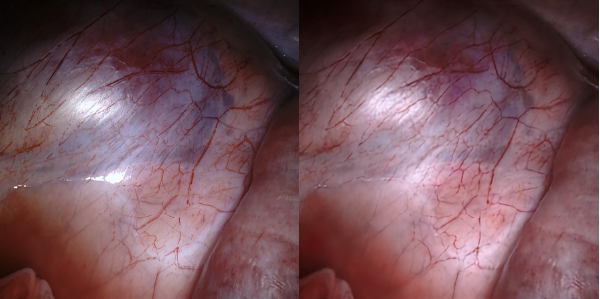

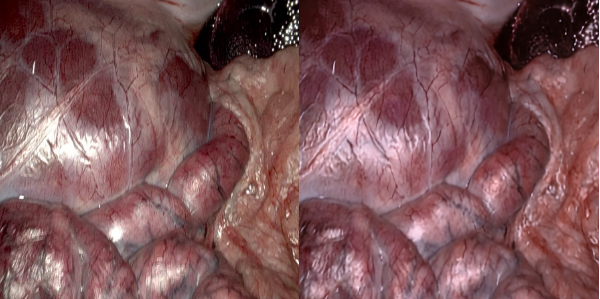

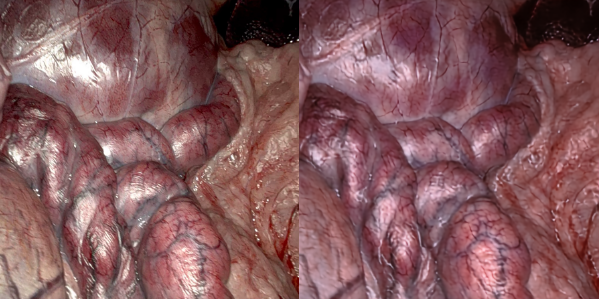

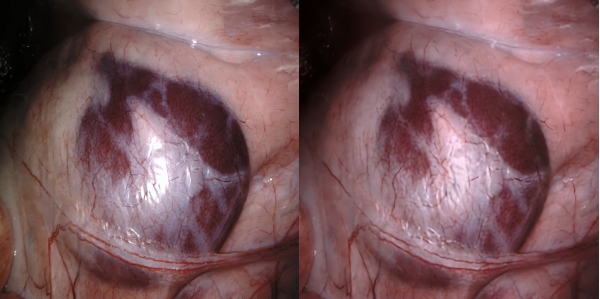

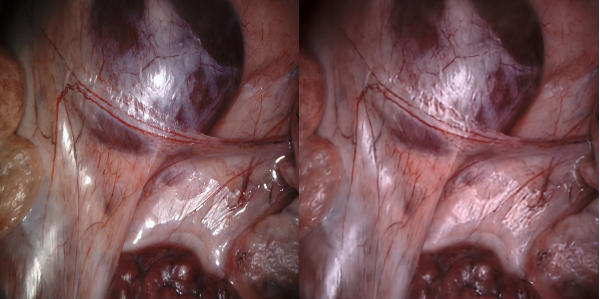

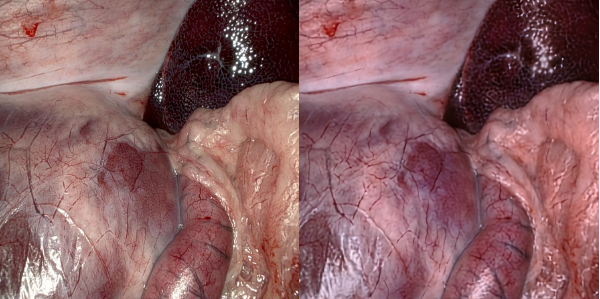

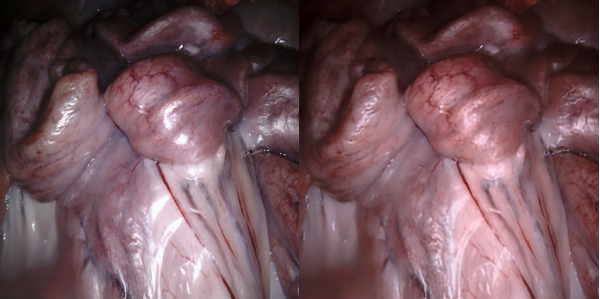

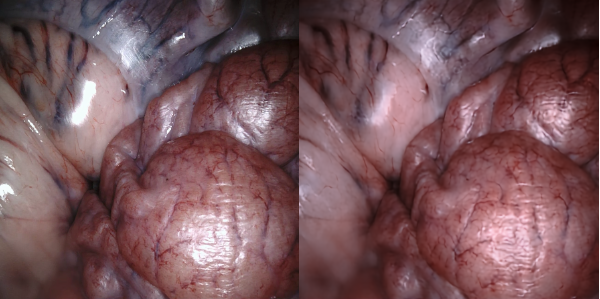

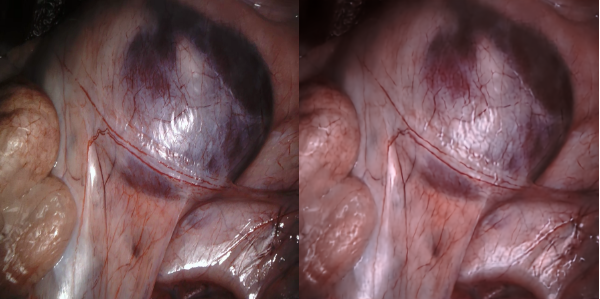

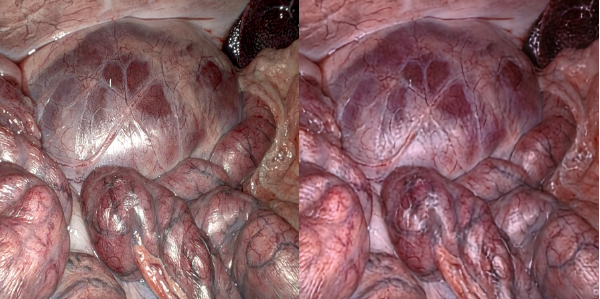

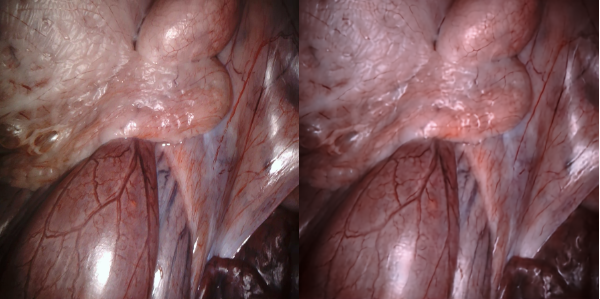

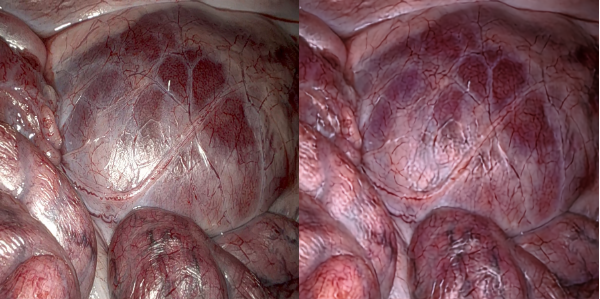

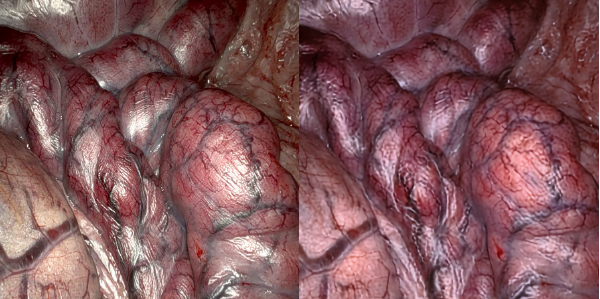

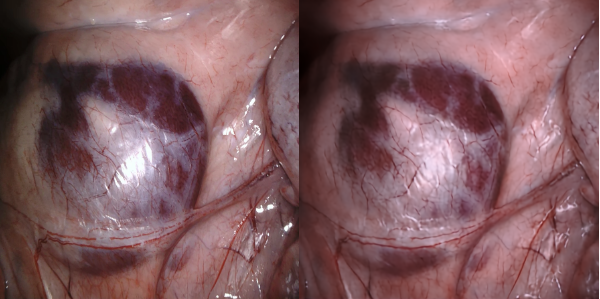

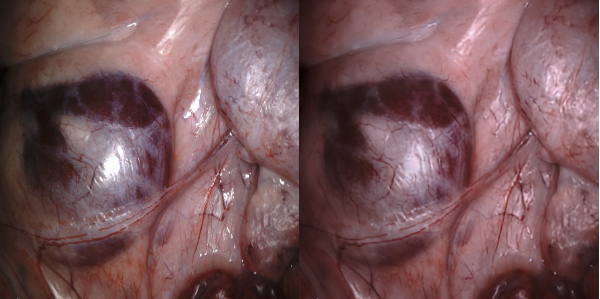

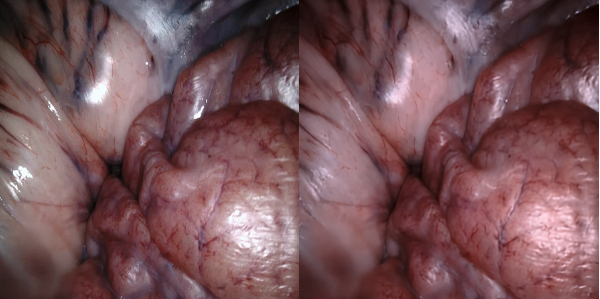

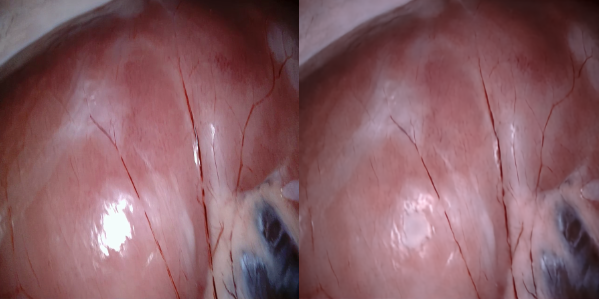

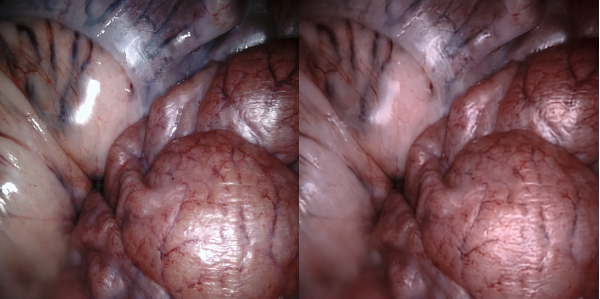

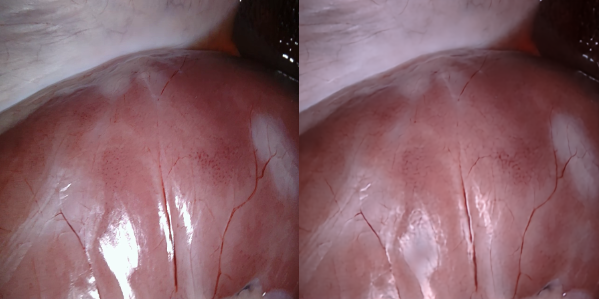

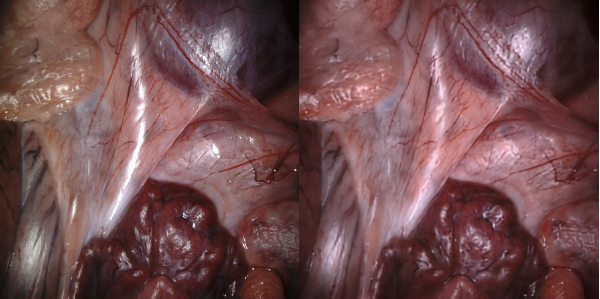

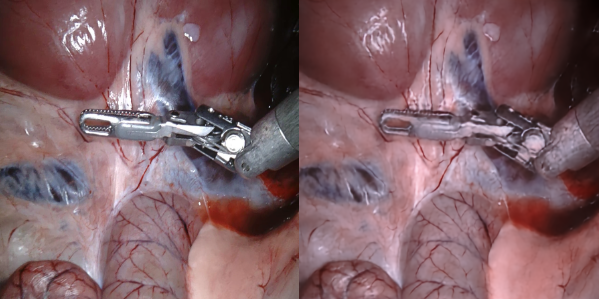

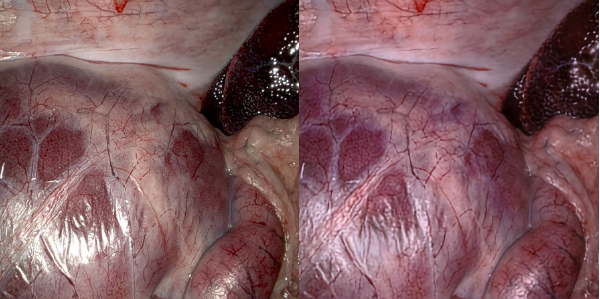

In [4]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for b, batch in enumerate(dataloader):
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    model_input = {"rgb": batch["raw"]}
    with torch.no_grad():
        modelout = model(model_input)
    rgb(
        panelize(
            rgb(batch["raw"], as_tensor=True, resize=(300, 300)),
            rgb(modelout["diffuse"][0], as_tensor=True, resize=(300, 300)),
        )
    )
    if b > 20:
        break
